# 98. BL Baseline — 20년 백테스트 (2006~2025)

99_baseline과 동일한 구조이나 **TRAIN_WINDOW=24개월**로 단축하여
2006년부터 예측 기간에 포함 (금융위기 2008~2009 포함).

| 항목 | 98_baseline | 99_baseline |
|------|------------|-------------|
| TRAIN_WINDOW | **24개월** | 60개월 |
| 예측 시작 | **2006-01** | 2009-01 |
| 예측 기간 | **~20년** | ~17년 |
| 금융위기 포함 | **O** | O |

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '98_2006_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW = 36    # 24개월 워밍업(2004-01~) → 2006-01부터 예측 (20년)
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2007-01-01'
Q_FIXED      = 0.003  # 월 0.3% = 연 3.6%
LAM_FIXED    = 2.5    # None이면 SPY 기반 동적 계산, 숫자면 고정 (He & Litterman 1999)

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')
print(f'LAM_FIXED = {LAM_FIXED}  (None이면 동적 계산)')

패널: (108180, 11)
예측 기간: 2007-01-31 ~ 2025-12-31 (228개월)
Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)
LAM_FIXED = 2.5  (None이면 동적 계산)


Ledoit-Wolf 진단 요약
p (종목 수):   391개 평균  (min 332 ~ max 466)
n (학습 월):   36개 평균
p/n 비율:      10.9 평균  (min 9.2 ~ max 12.9)
LW α (수축강도): 0.288 평균  (min 0.147 ~ max 0.510)
최소 고유값:    2.18e-03 평균  (→ 0이면 위험)
유효 랭크:      17.3 평균

✓  α=0.288 → 공분산 구조 적절히 반영.


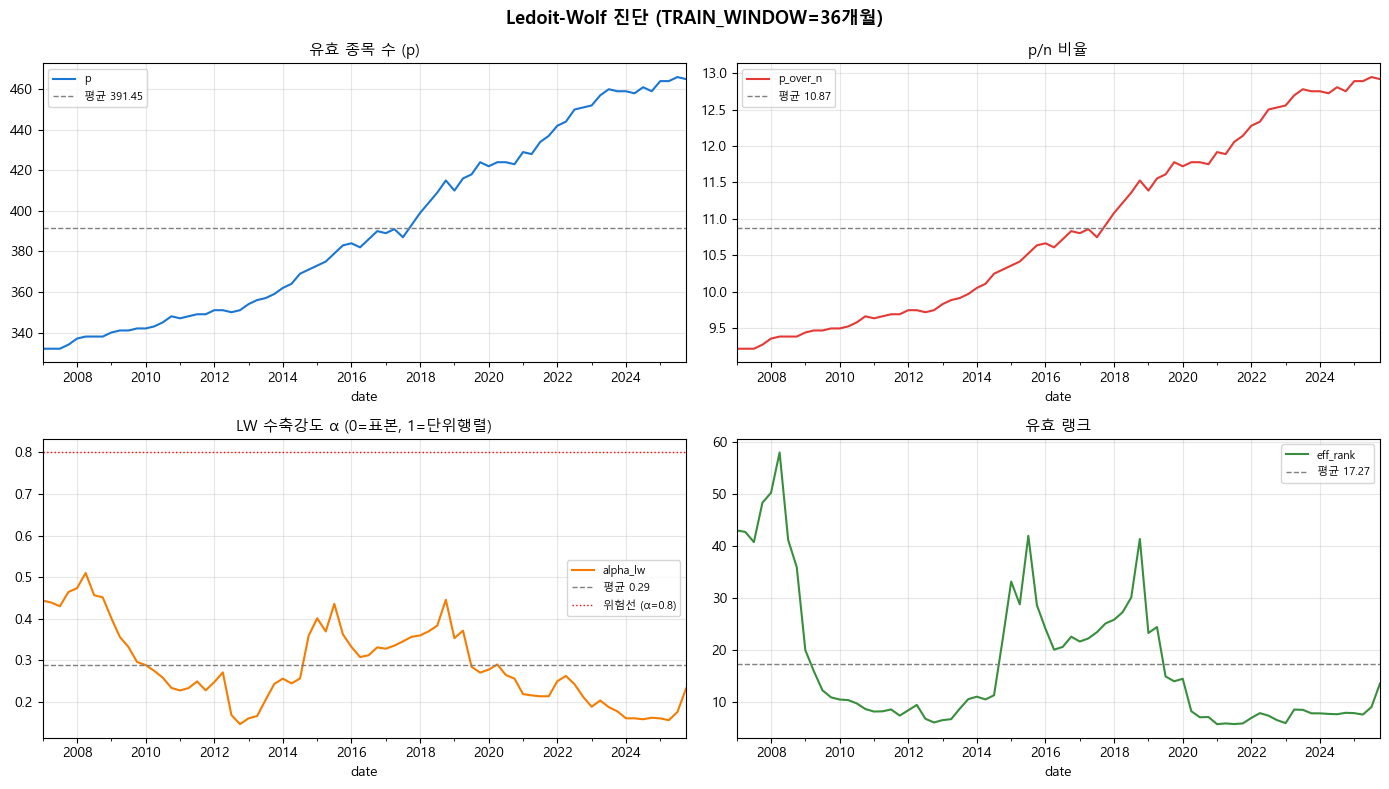

진단 완료


In [9]:
# ── Ledoit-Wolf 공분산 추정 진단 ────────────────────────────
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
import numpy as np

ret_pivot  = panel['ret_1m'].unstack('ticker')
diag_log = []

SAMPLE_EVERY = 3  # 매 3개월마다 샘플링 (240개월 → 80개 포인트)

for i, pred_date in enumerate(pred_dates):
    if i % SAMPLE_EVERY != 0:
        continue
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        n, p = ret_slice.shape          # n=행(월), p=열(종목)
        lw   = LedoitWolf().fit(ret_slice.values)
        alpha = lw.shrinkage_           # 수축강도 (0=표본공분산, 1=단위행렬)

        eigvals     = np.linalg.eigvalsh(lw.covariance_)
        min_eigval  = float(eigvals.min())
        eff_rank    = float(eigvals.sum()**2 / (eigvals**2).sum())  # effective rank

        diag_log.append({
            'date'       : pred_date,
            'n'          : n,
            'p'          : p,
            'p_over_n'   : p / n,
            'alpha_lw'   : alpha,
            'min_eigval' : min_eigval,
            'eff_rank'   : eff_rank,
        })
    except Exception as e:
        print(f'[에러] {pred_date.date()}: {e}')

diag = pd.DataFrame(diag_log).set_index('date')

# ── 요약 출력 ────────────────────────────────────────────────
print('=' * 52)
print('Ledoit-Wolf 진단 요약')
print('=' * 52)
print(f"p (종목 수):   {diag['p'].mean():.0f}개 평균  (min {diag['p'].min():.0f} ~ max {diag['p'].max():.0f})")
print(f"n (학습 월):   {diag['n'].mean():.0f}개 평균")
print(f"p/n 비율:      {diag['p_over_n'].mean():.1f} 평균  (min {diag['p_over_n'].min():.1f} ~ max {diag['p_over_n'].max():.1f})")
print(f"LW α (수축강도): {diag['alpha_lw'].mean():.3f} 평균  (min {diag['alpha_lw'].min():.3f} ~ max {diag['alpha_lw'].max():.3f})")
print(f"최소 고유값:    {diag['min_eigval'].mean():.2e} 평균  (→ 0이면 위험)")
print(f"유효 랭크:      {diag['eff_rank'].mean():.1f} 평균")
print()
alpha_mean = diag['alpha_lw'].mean()
if alpha_mean > 0.8:
    print(f'⚠️  α={alpha_mean:.3f} → 사실상 단위행렬. 공분산 구조 거의 무시됨.')
elif alpha_mean > 0.5:
    print(f'△  α={alpha_mean:.3f} → 수축 강함. 공분산 구조 일부만 반영.')
else:
    print(f'✓  α={alpha_mean:.3f} → 공분산 구조 적절히 반영.')

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Ledoit-Wolf 진단 (TRAIN_WINDOW={TRAIN_WINDOW}개월)', fontsize=13, fontweight='bold')

for ax, col, title, color in [
    (axes[0,0], 'p',         '유효 종목 수 (p)',        '#1976D2'),
    (axes[0,1], 'p_over_n',  'p/n 비율',                '#E53935'),
    (axes[1,0], 'alpha_lw',  'LW 수축강도 α (0=표본, 1=단위행렬)', '#F57C00'),
    (axes[1,1], 'eff_rank',  '유효 랭크',               '#388E3C'),
]:
    diag[col].plot(ax=ax, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.axhline(diag[col].mean(), color='gray', linestyle='--', linewidth=1, label=f'평균 {diag[col].mean():.2f}')
    if col == 'alpha_lw':
        ax.axhline(0.8, color='red', linestyle=':', linewidth=1, label='위험선 (α=0.8)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'lw_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('진단 완료')

In [10]:
# ── BL 함수 ──────────────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)

def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    if LAM_FIXED is not None:
        lam = LAM_FIXED
    else:
        lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
        lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam

def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P

def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)

def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)

def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints=[{'type':'eq','fun':lambda w: w.sum()-1}])
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)

print('BL 함수 정의 완료')

BL 함수 정의 완료


In [11]:
# ── Walk-forward (구성 진단 로깅 포함) ────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

bl_returns, capm_returns, spy_returns, error_log = [], [], [], []
composition_log = []

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)

        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)

        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()

        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)

        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, Q_FIXED, omega, TAU)

        w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
        w_capm = optimize_portfolio(pi,    Sigma, lam)

        # ── 다음달 수익률 적용 ─────────────────────────────────
        actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date is not None else np.nan

        bl_returns.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
        capm_returns.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_returns.append( {'date': pred_date, 'ret': r_spy})

        # ── 구성 진단 로깅 (추가 비용 없음) ────────────────────
        n_group       = max(1, int(len(valid_tix) * PCT_GROUP))
        sorted_by_vol = month_df['vol_21d'].sort_values()
        low_risk_tix  = sorted_by_vol.index[:n_group].tolist()
        high_risk_tix = sorted_by_vol.index[-n_group:].tolist()
        vol           = month_df['vol_21d']

        composition_log.append({
            'date'            : pred_date,
            'n_stocks'        : len(valid_tix),
            'bl_eff_n'        : 1.0 / float((w_bl**2).sum()),
            'bl_hhi'          : float((w_bl**2).sum()),
            'bl_top10_share'  : float(w_bl.nlargest(10).sum()),
            'bl_avg_vol'      : float((w_bl * vol).sum()),
            'bl_low_weight'   : float(w_bl[low_risk_tix].sum()),
            'bl_high_weight'  : float(w_bl[high_risk_tix].sum()),
            'bl_top1_weight'  : float(w_bl.max()),
            'bl_top1_ticker'  : w_bl.idxmax(),
            'capm_eff_n'      : 1.0 / float((w_capm**2).sum()),
            'capm_top10_share': float(w_capm.nlargest(10).sum()),
            'capm_avg_vol'    : float((w_capm * vol).sum()),
            'capm_low_weight' : float(w_capm[low_risk_tix].sum()),
            'capm_high_weight': float(w_capm[high_risk_tix].sum()),
        })

    except Exception as e:
        error_log.append({'date': pred_date, 'error': str(e)})
        if len(error_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

print(f'\n성공: {len(bl_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_log)}개월')

bl_ret   = pd.DataFrame(bl_returns).set_index('date')['ret']
capm_ret = pd.DataFrame(capm_returns).set_index('date')['ret']
spy_ret  = pd.DataFrame(spy_returns).set_index('date')['ret']
comp     = pd.DataFrame(composition_log).set_index('date')
comp.to_csv(DATA_DIR / 'portfolio_composition.csv')
print('DataFrame 생성 완료')

Walk-forward: 2007-01-31 ~ 2025-12-31
  2007-12-31 (12/228)
  2008-12-31 (24/228)
  2009-12-31 (36/228)
  2010-12-31 (48/228)
  2011-12-31 (60/228)
  2012-12-31 (72/228)
  2013-12-31 (84/228)
  2014-12-31 (96/228)
  2015-12-31 (108/228)
  2016-12-31 (120/228)
  2017-12-31 (132/228)
  2018-12-31 (144/228)
  2019-12-31 (156/228)
  2020-12-31 (168/228)
  2021-12-31 (180/228)
  2022-12-31 (192/228)
  2023-12-31 (204/228)
  2024-12-31 (216/228)
  2025-12-31 (228/228)

성공: 228개월 / 228개월
에러: 0개월
DataFrame 생성 완료


In [12]:
# ── 성과 분석 ─────────────────────────────────────────────────
ANN        = np.sqrt(12)
rf_monthly = rf_series.reindex(bl_ret.index).fillna(0)

def performance(ret, rf, label):
    excess  = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    print(f'[{label}]')
    print(f'  연환산 수익률: {ann_ret:.2%}')
    print(f'  연환산 변동성: {ann_vol:.2%}')
    print(f'  Sharpe Ratio:  {sharpe:.3f}')
    print(f'  누적 수익률:   {cum_ret:.2%}')
    print(f'  MDD:           {mdd:.2%}')
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

print('=' * 55)
print(f'포트폴리오 성과 비교 ({pred_dates[0].date()} ~ {pred_dates[-1].date()})')
print('=' * 55)
stats = []
for ret, label in [(bl_ret,'BL Baseline'), (capm_ret,'CAPM 균형'), (spy_ret,'S&P 500')]:
    stats.append(performance(ret, rf_monthly, label))
    print()

포트폴리오 성과 비교 (2007-01-31 ~ 2025-12-31)
[BL Baseline]
  연환산 수익률: 9.80%
  연환산 변동성: 13.50%
  Sharpe Ratio:  0.618
  누적 수익률:   436.55%
  MDD:           -54.79%

[CAPM 균형]
  연환산 수익률: 10.66%
  연환산 변동성: 17.95%
  Sharpe Ratio:  0.514
  누적 수익률:   449.61%
  MDD:           -68.03%

[S&P 500]
  연환산 수익률: 11.33%
  연환산 변동성: 15.44%
  Sharpe Ratio:  0.642
  누적 수익률:   nan%
  MDD:           -50.78%



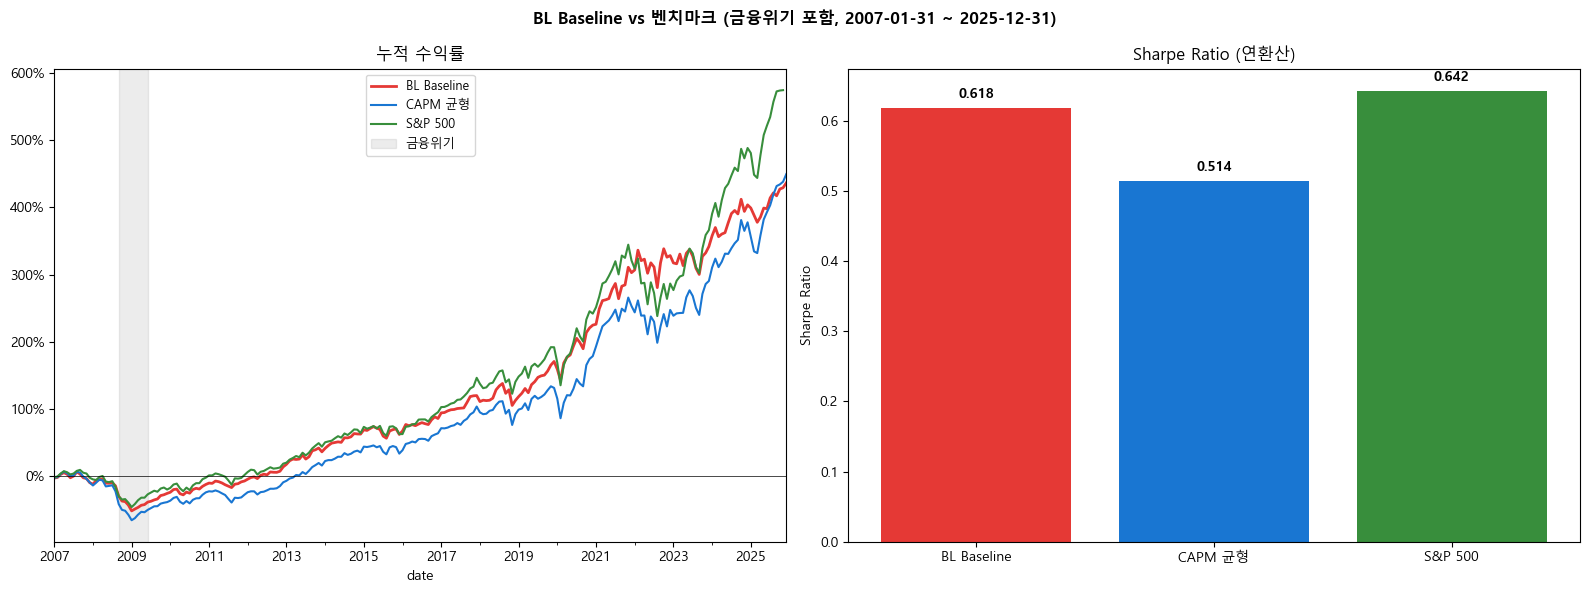

저장 완료


In [13]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'BL Baseline vs 벤치마크 (금융위기 포함, {pred_dates[0].date()} ~ {pred_dates[-1].date()})',
             fontsize=12, fontweight='bold')

ax = axes[0]
for ret, label, color, lw in [
    (bl_ret,   'BL Baseline', '#E53935', 2.0),
    (capm_ret, 'CAPM 균형',   '#1976D2', 1.5),
    (spy_ret,  'S&P 500',     '#388E3C', 1.5),
]:
    cum = (1 + ret).cumprod() - 1
    cum.plot(ax=ax, label=label, color=color, linewidth=lw)

# 금융위기 구간 음영
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='gray', label='금융위기')
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
labels  = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = ['#E53935', '#1976D2', '#388E3C']
bars    = ax.bar(labels, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_2006_performance.png', dpi=150, bbox_inches='tight')
plt.show()

result_df = pd.DataFrame({'bl': bl_ret, 'capm': capm_ret, 'spy': spy_ret})
result_df.to_csv(DATA_DIR / 'bl_2006_returns.csv')
print('저장 완료')

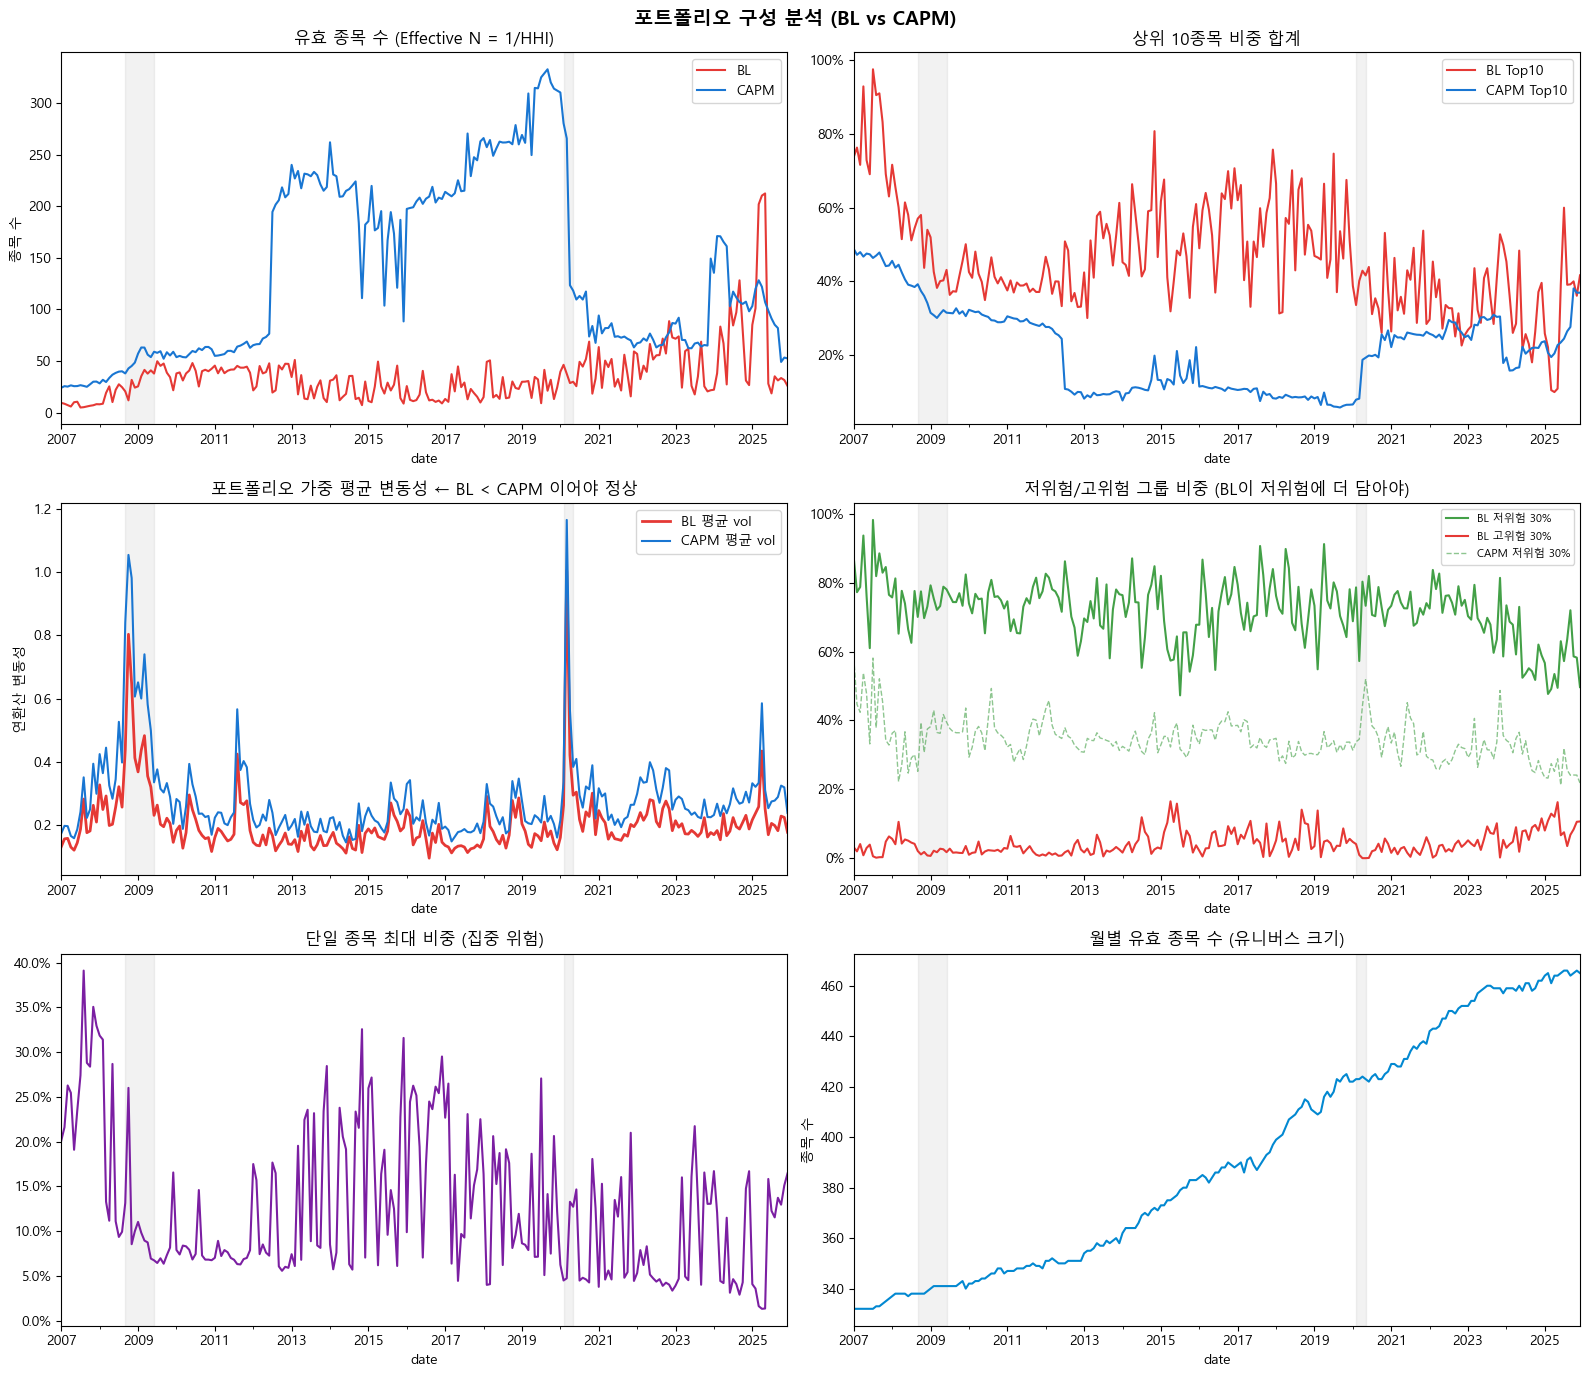

=== BL vs CAPM 구성 비교 ===
유효 종목 수:      BL 35.4개  /  CAPM 135.5개
Top10 집중도:      BL 46.1%  /  CAPM 21.7%
평균 변동성:       BL 0.2041  /  CAPM 0.2811  ← BL이 낮아야 정상
저위험 그룹 비중:  BL 71.9%  /  CAPM 34.2%
고위험 그룹 비중:  BL 4.3%  /  CAPM 26.8%


In [14]:
# ── 포트폴리오 구성 시각화 ───────────────────────────────────
crisis = [('2008-09-01','2009-06-30','GFC'), ('2020-02-01','2020-05-01','COVID')]

def shade(ax):
    for s, e, label in crisis:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.1, color='gray')

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('포트폴리오 구성 분석 (BL vs CAPM)', fontsize=14, fontweight='bold')

# ① 유효 종목 수
ax = axes[0, 0]
comp['bl_eff_n'].plot(ax=ax, color='#E53935', label='BL', linewidth=1.5)
comp['capm_eff_n'].plot(ax=ax, color='#1976D2', label='CAPM', linewidth=1.5)
ax.set_title('유효 종목 수 (Effective N = 1/HHI)')
ax.set_ylabel('종목 수')
ax.legend(); shade(ax)

# ② 상위 10종목 집중도
ax = axes[0, 1]
comp['bl_top10_share'].plot(ax=ax, color='#E53935', label='BL Top10', linewidth=1.5)
comp['capm_top10_share'].plot(ax=ax, color='#1976D2', label='CAPM Top10', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('상위 10종목 비중 합계')
ax.legend(); shade(ax)

# ③ 포트폴리오 평균 변동성 ← 핵심: BL < CAPM 이어야 저위험 틸트 확인
ax = axes[1, 0]
comp['bl_avg_vol'].plot(ax=ax, color='#E53935', label='BL 평균 vol', linewidth=2.0)
comp['capm_avg_vol'].plot(ax=ax, color='#1976D2', label='CAPM 평균 vol', linewidth=1.5)
ax.set_title('포트폴리오 가중 평균 변동성 ← BL < CAPM 이어야 정상')
ax.set_ylabel('연환산 변동성')
ax.legend(); shade(ax)

# ④ 저위험/고위험 그룹 비중
ax = axes[1, 1]
comp['bl_low_weight'].plot(ax=ax, color='#43A047', label='BL 저위험 30%', linewidth=1.5)
comp['bl_high_weight'].plot(ax=ax, color='#E53935', label='BL 고위험 30%', linewidth=1.5)
comp['capm_low_weight'].plot(ax=ax, color='#43A047', linestyle='--',
                              label='CAPM 저위험 30%', linewidth=1.0, alpha=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('저위험/고위험 그룹 비중 (BL이 저위험에 더 담아야)')
ax.legend(fontsize=8); shade(ax)

# ⑤ 단일 최대 비중
ax = axes[2, 0]
comp['bl_top1_weight'].plot(ax=ax, color='#7B1FA2', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('단일 종목 최대 비중 (집중 위험)')
shade(ax)

# ⑥ 유니버스 크기
ax = axes[2, 1]
comp['n_stocks'].plot(ax=ax, color='#0288D1', linewidth=1.5)
ax.set_title('월별 유효 종목 수 (유니버스 크기)')
ax.set_ylabel('종목 수')
shade(ax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'portfolio_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ─────────────────────────────────────────────────
print('=== BL vs CAPM 구성 비교 ===')
print(f"유효 종목 수:      BL {comp['bl_eff_n'].mean():.1f}개  /  CAPM {comp['capm_eff_n'].mean():.1f}개")
print(f"Top10 집중도:      BL {comp['bl_top10_share'].mean():.1%}  /  CAPM {comp['capm_top10_share'].mean():.1%}")
print(f"평균 변동성:       BL {comp['bl_avg_vol'].mean():.4f}  /  CAPM {comp['capm_avg_vol'].mean():.4f}  ← BL이 낮아야 정상")
print(f"저위험 그룹 비중:  BL {comp['bl_low_weight'].mean():.1%}  /  CAPM {comp['capm_low_weight'].mean():.1%}")
print(f"고위험 그룹 비중:  BL {comp['bl_high_weight'].mean():.1%}  /  CAPM {comp['capm_high_weight'].mean():.1%}")